# Student Submission

Fill in your IDs before submitting.

| | ID |
|---|----|
| Student 1 | _your ID_ |
| Student 2 | _your ID_ |

# Deep RL in MiniGrid — Final Project (2026 B)

## Overview
Train **deep RL agents from scratch** — one from each of the value-based, policy-based, and actor-critic families —
on two image-based MiniGrid environments. The agent sees only the
**raw rendered RGB image** of the grid and must learn to act from pixels. No external RL libraries for the core
algorithms — use PyTorch / TensorFlow only for the neural networks.

**Read the accompanying PDF first.** This notebook defines the environment APIs and the editable points; the PDF
defines what to deliver. The **report** is the primary deliverable and must be fully
self-contained: every graph, table, number, and discussion point lives there.

## Learning objectives
- Implement one algorithm from each family — **value-based** (e.g. DQN), **policy-based** (e.g. REINFORCE), and
  **actor-critic** (e.g. A2C) — from scratch, and compare them.
- Design observation preprocessing and reward shaping as composable wrappers.
- Choose hyperparameters and an exploration strategy deliberately, and justify them.
- Evaluate with clear metrics and plots, and communicate results in a concise report.

## The two environments
| Environment | Description | Win condition |
|---|---|---|
| **`SimpleRoomEnv`** | Empty 10×10 room (sanity check) | Step onto the green goal |
| **`ComplexEnv`** | Two rooms: key → locked door → water → lava → goal | Ferry water to extinguish the lava ring, then reach the goal |

Both expose the standard MiniGrid `Discrete(7)` action space and a **raw full-grid RGB observation** (`uint8`,
`H·tile × W·tile × 3`).

## What you build — and where
- **Observation preprocessing** — a `gym.ObservationWrapper` (e.g. grayscale, resize, channel-first, frame-stack).
- **Reward shaping** — a `gym.Wrapper` / `gym.RewardWrapper` that adds shaping on top of the sparse reward.
- **The agents** — for each family, the network(s), update rule, training loop, and evaluation (e.g. replay buffer
  + target net for DQN; a policy network for REINFORCE; actor + critic for A2C).

Do all of this **outside** the environments. Provided **example wrappers** and an **environment explorer** come first;
write your own wrappers and agents below the **"Your Code Below"** divider near the end. **The environment classes are
fixed**; see the full edit policy in the *Environments* section below.

## Reproducibility & integrity
- Seed Python, NumPy, and your DL framework, and document every hyperparameter.
- Submit (1) this notebook with all training/inference outputs and (2) the report PDF — a reader should understand your
  full methodology and results from the report alone.
- Discuss ideas freely, but code and write-up must be your own; cite any external resources (blog posts, papers, code).

# Setup

## Installs

In [1]:
# Auto-install any missing dependencies. Idempotent: pip is only invoked for packages
# that aren't already importable, so re-running this cell is safe and cheap on both Colab
# and a local Python / venv kernel.
from __future__ import annotations

import importlib
import subprocess
import sys


def _pip_install(*packages: str) -> None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *packages])


def _ensure(import_name: str, pip_name: str | None = None) -> None:
    try:
        importlib.import_module(import_name)
    except ImportError:
        _pip_install(pip_name or import_name)


_ensure("gymnasium")
_ensure("minigrid")
_ensure("numpy")
_ensure("matplotlib")
_ensure("cv2", "opencv-python")
_ensure("torch")
_ensure("imageio")
_ensure("imageio_ffmpeg", "imageio[ffmpeg]")   # mp4 backend for rollout videos
_ensure("ipywidgets")                          # inline env explorer (buttons)
# pyvirtualdisplay is only useful on a headless Linux host (e.g. Colab).
if "google.colab" in sys.modules or sys.platform.startswith("linux"):
    _ensure("pyvirtualdisplay")

objc[29945]: Class SDLApplication is implemented in both /Users/dypaul/Personal/Masters/Reinforcmment Learning/Ex3/src/.venv/lib/python3.13/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x114084a68) and /Users/dypaul/Personal/Masters/Reinforcmment Learning/Ex3/src/.venv/lib/python3.13/site-packages/cv2/.dylibs/libSDL2-2.0.0.dylib (0x11e0d8890). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[29945]: Class SDLAppDelegate is implemented in both /Users/dypaul/Personal/Masters/Reinforcmment Learning/Ex3/src/.venv/lib/python3.13/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x114084ab8) and /Users/dypaul/Personal/Masters/Reinforcmment Learning/Ex3/src/.venv/lib/python3.13/site-packages/cv2/.dylibs/libSDL2-2.0.0.dylib (0x11e0d88e0). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[29945]: Class SDLTranslatorResponder is implemented in both /Us

## Imports

In [2]:
from __future__ import annotations

import base64
import sys

import matplotlib.pyplot as plt
from IPython.display import HTML, display

# On headless Linux (e.g. Colab) MiniGrid's renderer needs a virtual display.
if "google.colab" in sys.modules or sys.platform.startswith("linux"):
    try:
        import pyvirtualdisplay
        pyvirtualdisplay.Display(visible=0, size=(1400, 900)).start()
    except Exception as exc:  # pragma: no cover
        print(f"[display] virtual display not started: {exc}")

%matplotlib inline
plt.rcParams["figure.figsize"] = (6.0, 5.0)

## Run controls (Run All safe)

Flip flags in the next cell, then **Run All**. Heavy SimpleRoom experiments default **OFF**.

ComplexEnv 6a/6b flags default **ON**. Re-enable older sections only when you want to reproduce them.


In [3]:
# === MASTER SWITCHES for Run All ============================================
# Heavy / already-done work defaults to False. Flip to True to re-run.
RUN = {
    # Template exploration (slow UI / videos)
    "env_explore_info": True,
    "env_explore_random": False,
    "wrapper_demo": True,
    "env_explorer_ui": True,
    # SimpleRoom pipeline / trains (already done locally)
    "obs_pipeline_viz": False,
    "simple_room_dqn": False,   # ~50k steps
    "exp6_search": False,       # 8 × 20k
    "exp6b_retrain": False,     # ~50k steps
    "exp7_gray": True,         # ~20k steps
    "step5_plots": True,       # needs history in memory / graphs JSON
    # ComplexEnv
    "complex_factory": True,    # make_complex_env + shaping
    "complex_sanity": True,     # quick random event check
    "complex_smoke": True,      # Step 6b DQN smoke
    # Step 6c overnight sweep (many hours) — default OFF for Run All.
    # Prefer launching from the Step 6c cell / terminal (already running in bg).
    "complex_overnight": False,
}

# If smoke/sanity is on, factory must run.
if RUN.get("complex_smoke") or RUN.get("complex_sanity"):
    RUN["complex_factory"] = True

print("RUN flags:")
for k, v in RUN.items():
    print(f"  {'ON ' if v else 'off'}  {k}")


RUN flags:
  ON   env_explore_info
  off  env_explore_random
  ON   wrapper_demo
  ON   env_explorer_ui
  off  obs_pipeline_viz
  off  simple_room_dqn
  off  exp6_search
  off  exp6b_retrain
  ON   exp7_gray
  ON   step5_plots
  ON   complex_factory
  ON   complex_sanity
  ON   complex_smoke
  off  complex_overnight


### Colab / remote path bootstrap

Your project lives on **Google Drive** at `MyDrive/RLEX3`. This cell:

1. Mounts Drive (approve the popup once)
2. Sets cwd + `sys.path` to `/content/drive/MyDrive/RLEX3`
3. Falls back to `git clone` only if Drive is missing

Then `import algorithms` / `import wrappers` work like locally.


In [4]:
# Repo-root bootstrap. The heavy Colab / Drive logic lives in colab/bootstrap.py —
# here we only make that package importable (trivial on a local kernel; on Colab we
# mount Drive, or clone the repo, so MyDrive/RLEX3 becomes visible), then delegate.
import sys
from pathlib import Path


def _repo_on_path() -> bool:
    for base in [
        Path.cwd(), *Path.cwd().parents,
        Path("/content/drive/MyDrive/RLEX3"),
        Path("/content/drive/My Drive/RLEX3"),
        Path("/content/RLEX3"),
    ]:
        if (base / "colab").is_dir() and (base / "algorithms").is_dir():
            if str(base) not in sys.path:
                sys.path.insert(0, str(base))
            return True
    return False


if not _repo_on_path() and Path("/content").is_dir():
    # Colab: mount Drive (repo usually on MyDrive/RLEX3), else clone into /content.
    try:
        from google.colab import drive
        drive.mount("/content/drive", force_remount=False)
    except Exception as exc:
        print(f"[bootstrap] Drive mount skipped: {exc}")
    if not _repo_on_path():
        import os
        import subprocess
        _url = os.environ.get("RLEX3_REPO_URL", "https://github.com/BlobDylan/RLEX3.git")
        try:
            subprocess.check_call(["git", "clone", _url, "/content/RLEX3"])
        except Exception as exc:
            print(f"[bootstrap] clone skipped: {exc}")
        _repo_on_path()

from colab import ensure_repo_root

REPO_ROOT = ensure_repo_root()

repo root: /Users/dypaul/Personal/Masters/Reinforcmment Learning/Ex3/src
cwd:       /Users/dypaul/Personal/Masters/Reinforcmment Learning/Ex3/src
sys.path[0]: /Users/dypaul/Personal/Masters/Reinforcmment Learning/Ex3/src
OK: algorithms/ and wrappers/ visible


## Display utils
Save a rollout to an `.mp4` and embed it inline. Auto-detects Colab vs local Jupyter — no configuration needed.

In [5]:
# Rollout-video helpers live in utils/video.py:
#   video_path(name)                 -> writable path under videos/
#   embed_mp4(path)                  -> inline <video> for Colab / Jupyter
#   random_rollout_video(env, ...)   -> one random episode -> mp4
#   agent_rollout_video(agent, ...)  -> one greedy episode  -> mp4
from utils import agent_rollout_video, embed_mp4, random_rollout_video, video_path

# Environments — definition & construction

Two MiniGrid environments are defined below. **Both are fixed** — only `max_steps` may be overridden at
construction. Everything else (preprocessing, reward shaping, action restriction) goes in **wrappers**.

**Action IDs** (standard MiniGrid `Discrete(7)`):

| ID | Name | Effect |
|---|---|---|
| 0 | `left` | turn 90° left (no move) |
| 1 | `right` | turn 90° right (no move) |
| 2 | `forward` | move one cell forward |
| 3 | `pickup` | pick up the object directly in front |
| 4 | `drop` | drop the carried object into the cell in front |
| 5 | `toggle` | activate the object in front (open a door with the matching key; **extinguish a lava tile while carrying water**) |
| 6 | `done` | no-op here |

**Coordinates.** Cells are `(x, y)` with `x` growing **rightward** and `y` **downward**. Facing `agent_dir`:
`0`=right, `1`=down, `2`=left, `3`=up.

## Environment 1 — SimpleRoomEnv (sanity)

**Task.** Navigate from a random start to the green goal in an empty room.

| Property | Value |
|---|---|
| Grid | 10×10 (8×8 walkable) |
| Agent start | random interior cell, random facing |
| Goal | a random corner |
| Actions | `Discrete(7)` (only turn/forward are needed) |
| Reward | sparse: `+1` on the goal, `0` otherwise |
| Observation | raw full-grid RGB `uint8` |

In [6]:
# SimpleRoomEnv is FIXED and lives in envs/simple_room_env.py (kept out of the
# notebook to keep experiments readable). Wrap it to add preprocessing / shaping;
# you may only override max_steps / tile_size.
from envs import SimpleRoomEnv

## Environment 2 — ComplexEnv (the task)

**Task — five stages: key → door → water → lava → goal.**
1. Pick up the **key** in the left room.
2. **Toggle** the locked partition **door** open (drop the key first if needed — only one object can be carried).
3. Pick up a **water ball** in the right room.
4. Face a **lava** tile and **toggle** to extinguish it; the tile clears and the ball is consumed. One ball per
   tile, so water must be **ferried repeatedly**.
5. Step onto the **goal** in the lava-ringed corner. Stepping on un-extinguished lava is **lethal**.

Objects may spawn in your path — the agent must learn to move them out of the way.

| Property | Value |
|---|---|
| Grid | 10×10, two rooms split by a partition wall (`partition_col=3`) |
| Agent start | `(1, 1)`, random facing |
| Key / Door | one key at a random left-room cell; one locked door at a random partition row |
| Water balls | a contiguous cluster in the top or bottom left of the right room (`water_corner`) |
| Lava | rings the goal corner; lethal until extinguished |
| Goal | top or bottom right-room corner (`goal_corner`) |
| Actions | `Discrete(7)` (turn / forward / pickup / drop / toggle all matter) |
| Reward | sparse: `+1` on the goal, `0` otherwise; lava death ends the episode with `0` |
| Observation | raw full-grid RGB `uint8` |

**Helper getters.** The observation is raw RGB, so there is no tabular state to read. `ComplexEnv` exposes
`is_*` / `prev_*` getters (current vs. start-of-step) plus position getters — see the class docstring (next
code cell) for the full list. They exist for wrappers (event detection) and analysis; reward may **not** use
geometry or distance.

**`info` dict** (from `step` / `reset`): `is_success`, `died_on_lava`, `extinguished_lava_count`, `n_lava`,
`extinguished_this_step`.

In [7]:
# ComplexEnv is FIXED and lives in envs/complex_env.py (kept out of the notebook to
# keep experiments readable). See the class docstring for the full list of helper
# getters (is_* / prev_* / *_positions). Wrap it to add preprocessing / reward
# shaping; you may only override max_steps / tile_size.
from envs import ComplexEnv

# Environment exploration

Get a feel for both envs before building anything — inspect the API and getters, the initial state, and a
random-action rollout. Nothing here is graded.

=== SimpleRoomEnv ===
obs shape / dtype : (40, 40, 3)  uint8
action space      : Discrete(7)
agent pos / dir   : (6, 4)  dir=1
goal_pos          : (1, 8)
info              : {}

=== ComplexEnv ===
obs shape / dtype : (320, 320, 3)  uint8
action space      : Discrete(7)
agent pos / dir   : (1, 1)  dir=3
door color / pos  : purple  (3, 1)
goal_pos          : (8, 1)
key   position    : (2, 3)  color=purple
water positions   : [(4, 1), (5, 1), (6, 1)]
lava  positions   : [(7, 1), (7, 2), (8, 2)]
-- curr state at reset --
carrying_key=False  carrying_water=False  in_right_room=False
door_open=False  door_locked=True  on_lava=False  on_goal=False
extinguished lava tiles : 0
info keys          : ['died_on_lava', 'extinguished_lava_count', 'extinguished_this_step', 'is_success', 'n_lava']


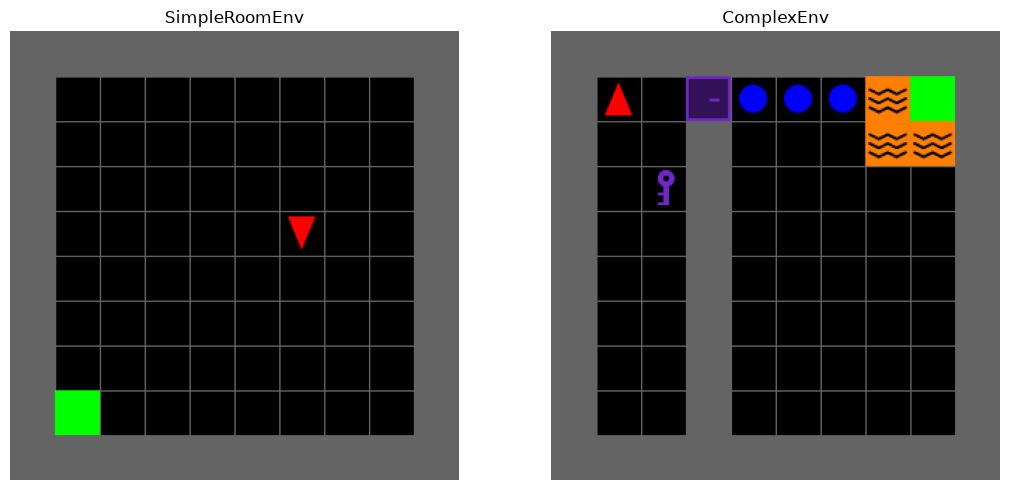

In [8]:
if not RUN.get("env_explore_info", False):
    print("⏭ skip: env_explore_info")
else:
    # Environment info + initial-state render for both envs, side by side.
    simple_env = SimpleRoomEnv(max_steps=100)
    s_obs, s_info = simple_env.reset(seed=42)

    env = ComplexEnv(max_steps=400)
    c_obs, c_info = env.reset(seed=42)

    print("=== SimpleRoomEnv ===")
    print(f"obs shape / dtype : {s_obs.shape}  {s_obs.dtype}")
    print(f"action space      : {simple_env.action_space}")
    print(f"agent pos / dir   : {simple_env.agent_pos}  dir={simple_env.agent_dir}")
    print(f"goal_pos          : {simple_env.goal_pos}")
    print(f"info              : {s_info}")

    print("\n=== ComplexEnv ===")
    print(f"obs shape / dtype : {c_obs.shape}  {c_obs.dtype}")
    print(f"action space      : {env.action_space}")
    print(f"agent pos / dir   : {env.agent_pos}  dir={env.agent_dir}")
    print(f"door color / pos  : {env.door_color}  {env.door_pos}")
    print(f"goal_pos          : {env.goal_pos}")
    print(f"key   position    : {env.key_position()}  color={env.key_color}")
    print(f"water positions   : {env.water_positions()}")
    print(f"lava  positions   : {env.lava_positions()}")
    print("-- curr state at reset --")
    print(f"carrying_key={env.is_carrying_key()}  carrying_water={env.is_carrying_water()}  "
          f"in_right_room={env.is_in_right_room()}")
    print(f"door_open={env.is_door_open()}  door_locked={env.is_door_locked()}  "
          f"on_lava={env.is_on_lava()}  on_goal={env.is_on_goal()}")
    print(f"extinguished lava tiles : {env.extinguished_lava_count()}")
    print(f"info keys          : {sorted(c_info)}")

    # Initial-state render, both envs side by side.
    fig, axes = plt.subplots(1, 2, figsize=(11, 5))
    for ax, e, title in ((axes[0], simple_env, "SimpleRoomEnv"), (axes[1], env, "ComplexEnv")):
        ax.imshow(e.render())
        ax.set_title(title)
        ax.axis("off")
    fig.tight_layout()
    plt.show()


In [9]:
if not RUN.get("env_explore_random", False):
    print("⏭ skip: env_explore_random")
else:
    # Random-action rollouts for both envs, shown side by side.
    # (Random actions rarely make progress on either env -- that's expected.)
    simple_video = video_path("SimpleRoomEnv_random.mp4")
    s_steps, s_total = random_rollout_video(simple_env, simple_video, max_steps=100, seed=1)
    print(f"SimpleRoomEnv random rollout: steps={s_steps}, total_reward={s_total:.2f}")

    complex_video = video_path("ComplexEnv_random.mp4")
    c_steps, c_total = random_rollout_video(env, complex_video, max_steps=100, seed=1)
    print(f"ComplexEnv  random rollout: steps={c_steps}, total_reward={c_total:.2f}")


    def _b64(path):
        with open(path, "rb") as f:
            return base64.b64encode(f.read()).decode()


    display(HTML(f"""
    <div style="display:flex; gap:16px; flex-wrap:wrap; align-items:flex-start;">
      <figure style="margin:0; text-align:center;">
        <figcaption><b>SimpleRoomEnv</b></figcaption>
        <video width="420" height="300" controls>
          <source src="data:video/mp4;base64,{_b64(simple_video)}" type="video/mp4">
        </video>
      </figure>
      <figure style="margin:0; text-align:center;">
        <figcaption><b>ComplexEnv</b></figcaption>
        <video width="420" height="300" controls>
          <source src="data:video/mp4;base64,{_b64(complex_video)}" type="video/mp4">
        </video>
      </figure>
    </div>
    """))


⏭ skip: env_explore_random


# Preprocessing & reward shaping — via wrappers

Everything outside the fixed envs is done with Gymnasium wrappers:

- **Observation preprocessing** → `gym.ObservationWrapper` (override `observation(obs)`, update `observation_space`).
- **Reward shaping** → `gym.Wrapper` / `gym.RewardWrapper` (modify the reward in `step`, reading the env getters).
- **Action subset** → `gym.ActionWrapper` (restrict the 7 actions).

Wrappers compose, e.g. `GrayscaleWrapper(ShapingWrapper(ComplexEnv()))`; reach the base env via `env.unwrapped`.
The next cell provides three **example wrappers** as starting points.

## Example wrappers (starter code)

Three minimal examples to build on, imported from `wrappers/` (definitions kept out of the notebook):
1. `GrayscaleWrapper` — RGB → single-channel grayscale.
2. `EventShapingWrapper` — scale the sparse goal reward and add a one-off event bonus via the env getters.
3. `ActionSubsetWrapper` — expose only a subset of the actions.

In [10]:
# Example starter wrappers live in wrappers/ (GrayscaleWrapper + ActionSubsetWrapper
# in wrappers/obs_action.py, EventShapingWrapper in wrappers/complex.py). Build your
# own wrappers alongside them.
from wrappers import ActionSubsetWrapper, EventShapingWrapper, GrayscaleWrapper

wrapped obs shape / dtype : (320, 320, 1)  uint8
observation_space         : Box(0, 255, (320, 320, 1), uint8)
action_space              : Discrete(6)  (subset of the 7 MiniGrid actions)


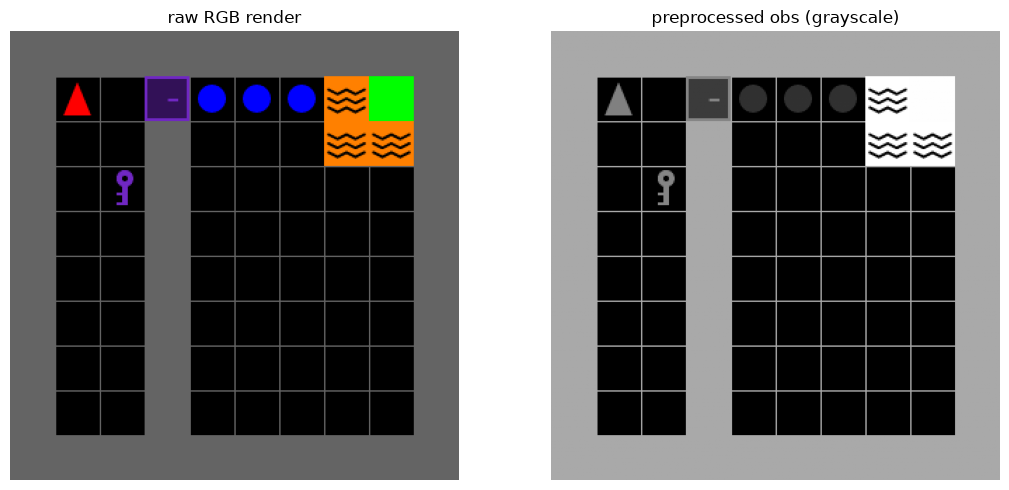

In [11]:
if not RUN.get("wrapper_demo", False):
    print("⏭ skip: wrapper_demo")
else:
    # Compose the example wrappers and inspect the result. Order matters.
    demo = ComplexEnv(max_steps=400)
    demo = EventShapingWrapper(demo, base_reward_scale=10.0, door_bonus=1.0, step_penalty=0.01)
    demo = ActionSubsetWrapper(demo, action_ids=(0, 1, 2, 3, 4, 5))
    demo = GrayscaleWrapper(demo)

    obs, info = demo.reset(seed=42)
    print(f"wrapped obs shape / dtype : {obs.shape}  {obs.dtype}")
    print(f"observation_space         : {demo.observation_space}")
    print(f"action_space              : {demo.action_space}  (subset of the 7 MiniGrid actions)")

    raw = demo.unwrapped.render()                       # full-color render of the same state
    fig, axes = plt.subplots(1, 2, figsize=(11, 5))
    axes[0].imshow(raw); axes[0].set_title("raw RGB render"); axes[0].axis("off")
    axes[1].imshow(obs.squeeze(), cmap="gray")
    axes[1].set_title("preprocessed obs (grayscale)"); axes[1].axis("off")
    plt.tight_layout(); plt.show()


## Environment explorer (drive an env by hand)

Step an env one action at a time with buttons, rendered inline, watching the reward, getters, and status
flags update. Point it at a **wrapped** env to see your shaped / scaled reward and preprocessed pipeline
(state read-outs come from `env.unwrapped`).

**Requires** `ipywidgets` and `env_explorer.py` in the working directory (in Colab, drag the file into
the **Files** panel). Safe to skip if a dependency is missing. Re-run after editing an env or a wrapper.

In [12]:
if not RUN.get("env_explorer_ui", False):
    print("⏭ skip: env_explorer_ui")
else:
    # Optional manual driver. Drive a *wrapped* env by hand to watch shaped reward + getters as you act.
    # (Pass `ComplexEnv` instead for the bare env.) On Colab: drag env_explorer.py into Files first.
    def make_explore_env():
        env = ComplexEnv(max_steps=400)
        env = EventShapingWrapper(env, base_reward_scale=10.0, door_bonus=1.0, step_penalty=0.01)
        env = ActionSubsetWrapper(env, action_ids=(0, 1, 2, 3, 4, 5))
        env = GrayscaleWrapper(env)
        return env


    try:
        from env_explorer import explore_env
        explore_env(make_explore_env, seed=None)        # or explore_env(ComplexEnv) for the raw env
    except Exception as exc:
        print(f"[explorer] not started: {exc}")


# Your Code Below

Everything below is yours — add as many cells as you need. Build your wrappers and agents here; see the PDF
for the deliverables. Good luck!

## Device

In [13]:
# CUDA (Colab GPU) → MPS (Mac) → CPU. Helper lives in utils/device.py.
from utils import describe_device, get_torch_device

device = get_torch_device()
print(f"Using device: {describe_device(device)}")

Using device: mps (Apple Metal — float32 only; fallback enabled)


## Algorithms

Shared agent interface in `algorithms/`. **DQN** is implemented; REINFORCE / A2C come later.

- `BaseAlgorithm` — common `select_action` / `train` / `evaluate` / `save` / `load`
- `DQN` — CNN Q-network, replay buffer, target net, ε-greedy


In [14]:
# IMPORTANT: Colab kernel cwd ≠ your terminal cwd. Re-pin the repo root defensively
# (colab/bootstrap.py). Agents live in algorithms/; shared helpers in utils/.
import importlib
from pathlib import Path

from colab import ensure_pkg_path

REPO_ROOT = ensure_pkg_path()

import algorithms
import utils
importlib.reload(utils.device)
importlib.reload(utils)
importlib.reload(algorithms.base)
importlib.reload(algorithms.dqn)
importlib.reload(algorithms)

from algorithms import BaseAlgorithm, DQN
from utils import describe_device, get_torch_device, seed_everything

print(BaseAlgorithm)
print(DQN)
print("algorithms from:", Path(algorithms.__file__).resolve())

using repo root: /Users/dypaul/Personal/Masters/Reinforcmment Learning/Ex3/src
cwd: /Users/dypaul/Personal/Masters/Reinforcmment Learning/Ex3/src
<class 'algorithms.base.BaseAlgorithm'>
<class 'algorithms.dqn.DQN'>
algorithms from: /Users/dypaul/Personal/Masters/Reinforcmment Learning/Ex3/src/algorithms/__init__.py


## Step 4 — Frozen observation pipeline (SimpleRoom)

Hard rule: **pixels only** into the network. Positions / getters are for shaping & EDA, not as CNN inputs.

### Locked stack (after Exp7)

| Stage | What | Shape (example) |
|-------|------|-----------------|
| 0 | `SimpleRoomEnv(tile_size=12)` raw RGB | `(120, 120, 3)` |
| 1 | `CropOuterWallsWrapper` — drop 1-cell outer wall | `(96, 96, 3)` |
| 2 | `TileInsetWrapper(keep_fraction=0.75)` — keep tile centers (`12→9`) | `(72, 72, 3)` |
| 3 | `GrayscaleWrapper` — Exp7: gray ≈ RGB under winner hypers | `(72, 72, 1)` |
| 4 | `ResizeObsWrapper(64)` nearest-neighbor | **`(64, 64, 1)`** |

Also on the env (not obs transforms): `SimpleRoomShapingWrapper(+50 / −0.1)` and `ActionSubsetWrapper({left, right, forward})`.

**Inside DQN:** HWC `uint8` → NCHW `float32` / 255. No frame stack (fully observable static room).

**Factory:** `make_simple_env(grayscale=True)` (default). Pass `grayscale=False` for RGB A/B.
For **ComplexEnv**, prefer RGB later (key / lava / water are color-coded).

### Observation readability — prove the pipeline

Same seed, `tile_size=12`. Top row = stages through the **frozen grayscale** CNN input. Bottom = one tile zoomed (red box = kept center).


In [15]:
if not RUN.get("obs_pipeline_viz", False):
    print("⏭ skip: obs_pipeline_viz")
else:
    from matplotlib.patches import Rectangle
    from wrappers import CropOuterWallsWrapper, ResizeObsWrapper, TileInsetWrapper

    _VIZ_SEED = 42
    _TILE = 12
    _KEEP = 0.75
    _CNN = 64

    # --- build each stage (same seed) ---
    raw_env = SimpleRoomEnv(max_steps=100, tile_size=_TILE)
    raw_obs, _ = raw_env.reset(seed=_VIZ_SEED)
    agent_cell = tuple(int(v) for v in raw_env.unwrapped.agent_pos)  # (x, y) in grid cells

    wall_env = CropOuterWallsWrapper(SimpleRoomEnv(max_steps=100, tile_size=_TILE))
    wall_obs, _ = wall_env.reset(seed=_VIZ_SEED)

    inset_env = TileInsetWrapper(
        CropOuterWallsWrapper(SimpleRoomEnv(max_steps=100, tile_size=_TILE)),
        keep_fraction=_KEEP,
    )
    inset_obs, _ = inset_env.reset(seed=_VIZ_SEED)

    # Frozen training stack: grayscale → resize 64 (Exp7).
    cnn_env = ResizeObsWrapper(
        GrayscaleWrapper(
            TileInsetWrapper(
                CropOuterWallsWrapper(SimpleRoomEnv(max_steps=100, tile_size=_TILE)),
                keep_fraction=_KEEP,
            )
        ),
        size=_CNN,
    )
    cnn_obs, _ = cnn_env.reset(seed=_VIZ_SEED)

    # Agent tile in wall-cropped image: grid has a 1-cell outer wall, so interior index = pos-1
    ax_i, ay_i = agent_cell[0] - 1, agent_cell[1] - 1
    tile = wall_obs[
        ay_i * _TILE : (ay_i + 1) * _TILE,
        ax_i * _TILE : (ax_i + 1) * _TILE,
    ]
    inner, ins = inset_env.inner, inset_env.inset
    tile_center = tile[ins : ins + inner, ins : ins + inner]

    # --- figure ---
    fig = plt.figure(figsize=(14, 8))
    gs = fig.add_gridspec(2, 4, height_ratios=[1.2, 1.0], hspace=0.35, wspace=0.25)

    # Row 0: full pipeline
    titles = [
        f"1. raw RGB\n{raw_obs.shape}",
        f"2. wall-crop\n{wall_obs.shape}",
        f"3. + tile-inset ({_TILE}→{inner})\n{inset_obs.shape}",
        f"4. CNN input (gray→{_CNN})\n{cnn_obs.shape}",
    ]
    images = [raw_obs, wall_obs, inset_obs, cnn_obs.squeeze(-1)]
    cmaps = [None, None, None, "gray"]
    for col, (img, title, cmap) in enumerate(zip(images, titles, cmaps)):
        ax = fig.add_subplot(gs[0, col])
        ax.imshow(img, cmap=cmap, interpolation="nearest")
        ax.set_title(title, fontsize=11)
        ax.set_xticks([])
        ax.set_yticks([])

    # Row 1: zoom one tile — before inset / keep box / after inset / size bars
    ax0 = fig.add_subplot(gs[1, 0])
    ax0.imshow(tile, interpolation="nearest")
    ax0.add_patch(
        Rectangle(
            (ins - 0.5, ins - 0.5),
            inner,
            inner,
            fill=False,
            edgecolor="red",
            linewidth=2,
        )
    )
    ax0.set_title(f"Agent tile {_TILE}×{_TILE}\nred = kept center", fontsize=11)
    ax0.set_xticks([])
    ax0.set_yticks([])

    ax1 = fig.add_subplot(gs[1, 1])
    ax1.imshow(tile_center, interpolation="nearest")
    ax1.set_title(f"Extracted center {inner}×{inner}\n(no resize/blur)", fontsize=11)
    ax1.set_xticks([])
    ax1.set_yticks([])

    ax2 = fig.add_subplot(gs[1, 2])
    # Draw tile grid on wall-crop vs inset so packing is visible
    show = wall_obs.copy()
    ax2.imshow(show, interpolation="nearest")
    for k in range(0, show.shape[0] + 1, _TILE):
        ax2.axhline(k - 0.5, color="cyan", lw=0.4, alpha=0.8)
        ax2.axvline(k - 0.5, color="cyan", lw=0.4, alpha=0.8)
    ax2.set_title("Wall-crop + tile grid", fontsize=11)
    ax2.set_xticks([])
    ax2.set_yticks([])

    ax3 = fig.add_subplot(gs[1, 3])
    show_i = inset_obs.copy()
    ax3.imshow(show_i, interpolation="nearest")
    for k in range(0, show_i.shape[0] + 1, inner):
        ax3.axhline(k - 0.5, color="lime", lw=0.4, alpha=0.8)
        ax3.axvline(k - 0.5, color="lime", lw=0.4, alpha=0.8)
    ax3.set_title("After inset + denser grid", fontsize=11)
    ax3.set_xticks([])
    ax3.set_yticks([])

    fig.suptitle(
        f"Obs pipeline (seed={_VIZ_SEED}, agent cell={agent_cell})  |  "
        f"pixels/tile: {_TILE * _TILE} → {inner * inner}  "
        f"({100 * (1 - (inner * inner) / (_TILE * _TILE)):.0f}% discarded per tile)",
        fontsize=12,
        y=1.02,
    )
    plt.show()

    print(
        f"wall-crop: {wall_obs.shape}  →  inset: {inset_obs.shape}  →  CNN: {cnn_obs.shape}  |  "
        f"inset={ins}px/side, keep_fraction={_KEEP}"
    )

    raw_env.close()
    wall_env.close()
    inset_env.close()
    cnn_env.close()


⏭ skip: obs_pipeline_viz


### DQN — sanity check on `SimpleRoomEnv`

Uses the **frozen RGB pipeline** above + action subset `{left, right, forward}` + shaped reward. Hypers = Exp6 trial-4 / Exp6b winner. Once this is solved, move to graphs (Step 5) then `ComplexEnv` (Step 6).


In [16]:
from wrappers import (
    CropOuterWallsWrapper,
    ResizeObsWrapper,
    SimpleRoomShapingWrapper,
    TileInsetWrapper,
)

# High-res tiles → wall-crop → tile-inset → grayscale → resize for CNN.
_TRAIN_TILE = 12
_KEEP_FRAC = 0.75  # ~25% linear trim per tile (12→9 center)
_CNN_SIZE = 64


def make_simple_env(
    tile_size: int = _TRAIN_TILE,
    keep_fraction: float = _KEEP_FRAC,
    cnn_size: int = _CNN_SIZE,
    grayscale: bool = True,  # Exp7: gray ≈ RGB; cheaper than RGB
):
    env = SimpleRoomEnv(max_steps=100, tile_size=tile_size)
    env = SimpleRoomShapingWrapper(env, goal_scale=50.0, step_penalty=0.1)
    env = ActionSubsetWrapper(env, action_ids=(0, 1, 2))
    env = CropOuterWallsWrapper(env)
    env = TileInsetWrapper(env, keep_fraction=keep_fraction)
    if grayscale:
        env = GrayscaleWrapper(env)
    env = ResizeObsWrapper(env, size=cnn_size)
    return env


# agent_rollout_video comes from utils (imported in the Display utils cell above).

_probe = make_simple_env()
obs_shape = _probe.observation_space.shape
n_actions = _probe.action_space.n
_probe.close()
_inner = max(1, int(round(_TRAIN_TILE * _KEEP_FRAC)))
print(
    f"obs_shape={obs_shape}  "
    f"(tile={_TRAIN_TILE} → wall-crop → tile-inset {_TRAIN_TILE}→{_inner} → "
    f"gray → resize {_CNN_SIZE})  # Exp7 default"
)

# --- heavy train (skipped on Run All unless RUN["simple_room_dqn"]=True) ---
if not RUN.get("simple_room_dqn", False):
    print("⏭ skip: simple_room_dqn train (factory above is ready)")
else:
    dqn = DQN(
        obs_shape,
        n_actions,
        device=device,
        seed=0,
        gamma=0.95,
        lr=2.81e-4,
        batch_size=128,
        buffer_size=50_000,
        learning_starts=1_000,
        train_freq=1,
        tau=0.001,
        double_dqn=True,
        eps_start=1.0,
        eps_end=0.15,
        eps_decay_steps=20_000,
    )
    print(dqn)

    dqn_history = dqn.train(make_simple_env, total_timesteps=50_000, log_every=1_000)

    diag_env = make_simple_env()
    print("greedy diagnose:", dqn.diagnose_greedy(diag_env, seed=42))
    diag_env.close()

    eval_env = make_simple_env()
    print("eval:", dqn.evaluate(eval_env, n_episodes=10, seed=100))
    eval_env.close()

    dqn_video = video_path("dqn_simple_room.mp4")
    vid_env = make_simple_env()
    v_steps, v_return = agent_rollout_video(dqn, vid_env, dqn_video, max_steps=100, seed=42)
    vid_env.close()
    print(f"video: {dqn_video}  steps={v_steps}  return={v_return:.2f}")
    embed_mp4(dqn_video)

obs_shape=(64, 64, 1)  (tile=12 → wall-crop → tile-inset 12→9 → gray → resize 64)  # Exp7 default
⏭ skip: simple_room_dqn train (factory above is ready)


### Exp6 — random hyperparameter search (same DQN, frozen obs)

Keep the RGB preprocess fixed. Sample a handful of DQN hypers, train each for a **short** budget, rank by **greedy `success_rate`**. Best config can then be re-trained for a full 50k run. Dueling DQN stays as the next architecture option if search does not unlock greedy success.


In [17]:
if not RUN.get("exp6_search", False):
    print("⏭ skip: exp6_search")
else:
    import importlib
    import algorithms.hparam_search as _hs
    importlib.reload(_hs)
    from algorithms import format_search_leaderboard, random_search_dqn

    # Requires make_simple_env from the cell above (RGB pipeline).
    _probe = make_simple_env()
    _obs_shape = _probe.observation_space.shape
    _n_actions = _probe.action_space.n
    _probe.close()
    assert _obs_shape[-1] == 3, f"expected RGB obs, got {_obs_shape}"

    # Short trials for iteration speed — bump n_trials / timesteps when you have GPU time.
    _SEARCH_TRIALS = 8
    _SEARCH_STEPS = 20_000

    search_results = random_search_dqn(
        make_simple_env,
        obs_shape=_obs_shape,
        n_actions=_n_actions,
        device=device,
        n_trials=_SEARCH_TRIALS,
        total_timesteps=_SEARCH_STEPS,
        eval_episodes=10,
        seed=0,
    )

    print("\n=== leaderboard (by greedy success_rate) ===")
    print(format_search_leaderboard(search_results, top_k=min(5, len(search_results))))

    best = search_results[0]
    print("\nbest hparams:")
    for k, v in best["hparams"].items():
        print(f"  {k}: {v}")
    print("best eval:", best["eval"])
    print("best diagnose action_counts:", best["diagnose"]["action_counts"])


⏭ skip: exp6_search


### Exp6b — full 50k retrain with search winner

Uses `search_results[0]["hparams"]` from the cell above (trial 4: ~90% greedy at 20k). Re-run search first if `search_results` is missing.


In [18]:
if not RUN.get("exp6b_retrain", False):
    print("⏭ skip: exp6b_retrain")
else:
    # Fallback if search_results isn't in memory (Exp6 trial-4 winner).
    _BEST_HPARAMS = {
        "lr": 2.81e-4,
        "gamma": 0.95,
        "batch_size": 128,
        "train_freq": 1,
        "tau": 0.001,
        "eps_start": 1.0,
        "eps_end": 0.15,
        "eps_decay_steps": 20_000,
        "learning_starts": 1_000,
        "double_dqn": True,
        "buffer_size": 50_000,
    }
    _hp = search_results[0]["hparams"] if "search_results" in dir() and search_results else _BEST_HPARAMS
    print("retrain hparams:", {k: (round(v, 6) if isinstance(v, float) else v) for k, v in _hp.items()})

    _probe = make_simple_env()
    _obs_shape = _probe.observation_space.shape
    _n_actions = _probe.action_space.n
    _probe.close()

    dqn_best = DQN(_obs_shape, _n_actions, device=device, seed=0, **_hp)
    print(dqn_best)
    dqn_best_history = dqn_best.train(make_simple_env, total_timesteps=50_000, log_every=1_000)

    diag_env = make_simple_env()
    print("greedy diagnose:", dqn_best.diagnose_greedy(diag_env, seed=42))
    diag_env.close()

    eval_env = make_simple_env()
    print("eval:", dqn_best.evaluate(eval_env, n_episodes=20, seed=100))
    eval_env.close()

    dqn_best_video = video_path("dqn_simple_room_best.mp4")
    vid_env = make_simple_env()
    v_steps, v_return = agent_rollout_video(dqn_best, vid_env, dqn_best_video, max_steps=100, seed=42)
    vid_env.close()
    print(f"video: {dqn_best_video}  steps={v_steps}  return={v_return:.2f}")
    embed_mp4(dqn_best_video)

    from utils import graphs_dir, save_training_history
    _hist_path = graphs_dir() / "dqn_best_history.json"
    save_training_history(dqn_best_history, _hist_path)
    print(f"history saved: {_hist_path}")

⏭ skip: exp6b_retrain


### Exp7 — grayscale A/B with Exp6 winner hypers — **PASSED**

Same winner hypers as Exp6b, **grayscale** @ **20k**. Result: greedy **90%**, forward-dominant diagnose, no spin — matches RGB Exp6 trial 4. Exp4 spin was hypers, not color. **SimpleRoom default → grayscale**; keep RGB for ComplexEnv.


In [19]:
if not RUN.get("exp7_gray", False):
    print("⏭ skip: exp7_gray")
else:
    from wrappers import (
        CropOuterWallsWrapper,
        ResizeObsWrapper,
        SimpleRoomShapingWrapper,
        TileInsetWrapper,
    )

    # Exp7: grayscale + Exp6 winner hypers @ 20k (compare to RGB trial-4 ~90%).
    # Self-contained — does not require re-running the 50k RGB train cell.
    _BEST_HPARAMS = {
        "lr": 2.81e-4,
        "gamma": 0.95,
        "batch_size": 128,
        "train_freq": 1,
        "tau": 0.001,
        "eps_start": 1.0,
        "eps_end": 0.15,
        "eps_decay_steps": 20_000,
        "learning_starts": 1_000,
        "double_dqn": True,
        "buffer_size": 50_000,
    }
    _hp = (
        search_results[0]["hparams"]
        if "search_results" in dir() and search_results
        else _BEST_HPARAMS
    )

    def make_simple_env_gray(
        tile_size: int = 12,
        keep_fraction: float = 0.75,
        cnn_size: int = 64,
    ):
        """Same SimpleRoom stack as RGB baseline, but grayscale before resize."""
        env = SimpleRoomEnv(max_steps=100, tile_size=tile_size)
        env = SimpleRoomShapingWrapper(env, goal_scale=50.0, step_penalty=0.1)
        env = ActionSubsetWrapper(env, action_ids=(0, 1, 2))
        env = CropOuterWallsWrapper(env)
        env = TileInsetWrapper(env, keep_fraction=keep_fraction)
        env = GrayscaleWrapper(env)
        env = ResizeObsWrapper(env, size=cnn_size)
        return env

    _probe = make_simple_env_gray()
    _obs_g = _probe.observation_space.shape
    _n_act = _probe.action_space.n
    _probe.close()
    assert _obs_g[-1] == 1, f"expected grayscale (H,W,1), got {_obs_g}"
    print(
        "Exp7 grayscale obs:", _obs_g,
        "hparams:", {k: (round(v, 6) if isinstance(v, float) else v) for k, v in _hp.items()},
    )

    dqn_gray = DQN(_obs_g, _n_act, device=device, seed=0, **_hp)
    print(dqn_gray)
    dqn_gray_history = dqn_gray.train(make_simple_env_gray, total_timesteps=20_000, log_every=1_000)

    diag_env = make_simple_env_gray()
    print("greedy diagnose:", dqn_gray.diagnose_greedy(diag_env, seed=42))
    diag_env.close()

    eval_env = make_simple_env_gray()
    print("eval:", dqn_gray.evaluate(eval_env, n_episodes=20, seed=100))
    eval_env.close()

    dqn_gray_video = video_path("dqn_simple_room_gray_exp7.mp4")
    vid_env = make_simple_env_gray()
    v_steps, v_return = agent_rollout_video(dqn_gray, vid_env, dqn_gray_video, max_steps=100, seed=42)
    vid_env.close()
    print(f"video: {dqn_gray_video}  steps={v_steps}  return={v_return:.2f}")
    embed_mp4(dqn_gray_video)

    # Persist for Step 5 / kernel restarts
    from utils import graphs_dir, save_training_history
    _hist_path = graphs_dir() / "dqn_gray_history.json"
    save_training_history(dqn_gray_history, _hist_path)
    print(f"history saved: {_hist_path}")

Exp7 grayscale obs: (64, 64, 1) hparams: {'lr': 0.000281, 'gamma': 0.95, 'batch_size': 128, 'train_freq': 1, 'tau': 0.001, 'eps_start': 1.0, 'eps_end': 0.15, 'eps_decay_steps': 20000, 'learning_starts': 1000, 'double_dqn': True, 'buffer_size': 50000}
DQN(obs_shape=(64, 64, 1), n_actions=3, device=mps, steps=0)
steps=   1786  episodes=   20  return= -10.00  mean20=   1.07  succ20=20.0%  eps=0.924
steps=   3616  episodes=   40  return= -10.00  mean20=  -1.65  succ20=15.0%  eps=0.846
steps=   5471  episodes=   60  return= -10.00  mean20=   0.73  succ20=20.0%  eps=0.767
steps=   7233  episodes=   80  return= -10.00  mean20=   3.69  succ20=25.0%  eps=0.693
steps=   9072  episodes=  100  return= -10.00  mean20=   3.31  succ20=25.0%  eps=0.614
steps=  10267  episodes=  120  return=  47.00  mean20=  29.03  succ20=70.0%  eps=0.564
steps=  11662  episodes=  140  return= -10.00  mean20=  13.03  succ20=40.0%  eps=0.504
steps=  12900  episodes=  160  return=  40.90  mean20=  26.31  succ20=65.0%  ep

## Step 5 — Training metrics & graphs

Assignment plots (episode on the x-axis; rolling mean window = 20):

1. **Return** per episode
2. **Length** (steps per episode)
3. **Success rate** (rolling)
4. **Cumulative env steps** vs episode (shared training-budget axis)

Helpers live in `utils/plotting.py` and write PNGs under `graphs/`. Prefer the latest in-memory history (`dqn_gray_history` / `dqn_best_history` / …); otherwise load a saved JSON.

using dqn_gray_history (Exp7 gray @ 20k)  |  episodes=418  |  saved /Users/dypaul/Personal/Masters/Reinforcmment Learning/Ex3/src/graphs/dqn_gray_history.json


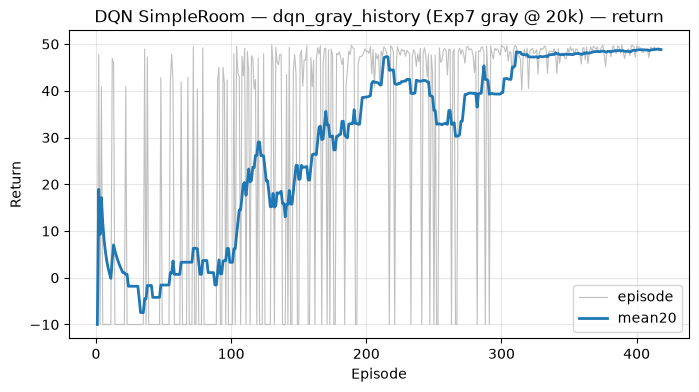

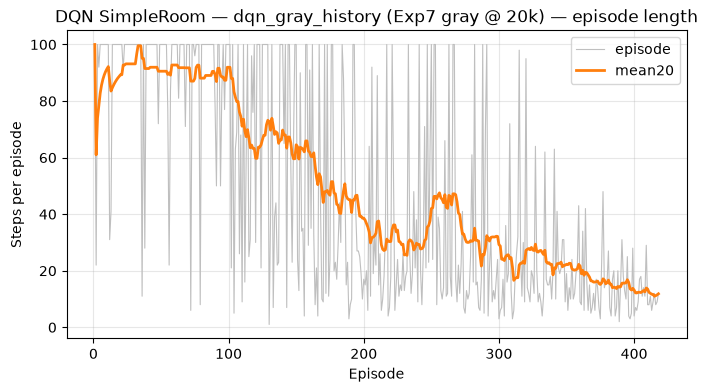

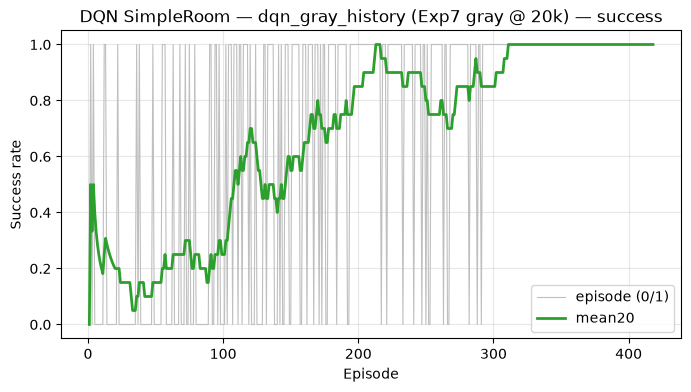

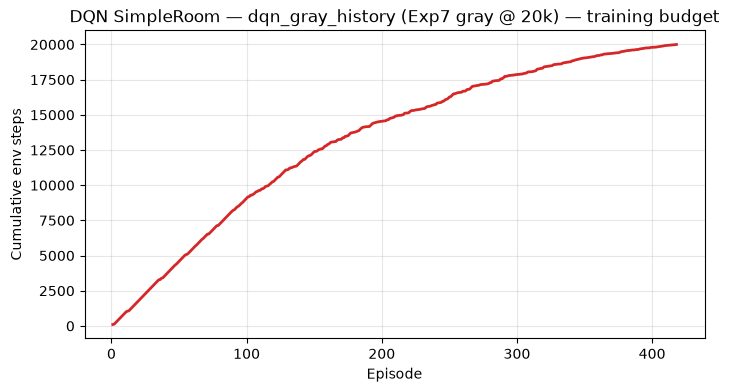

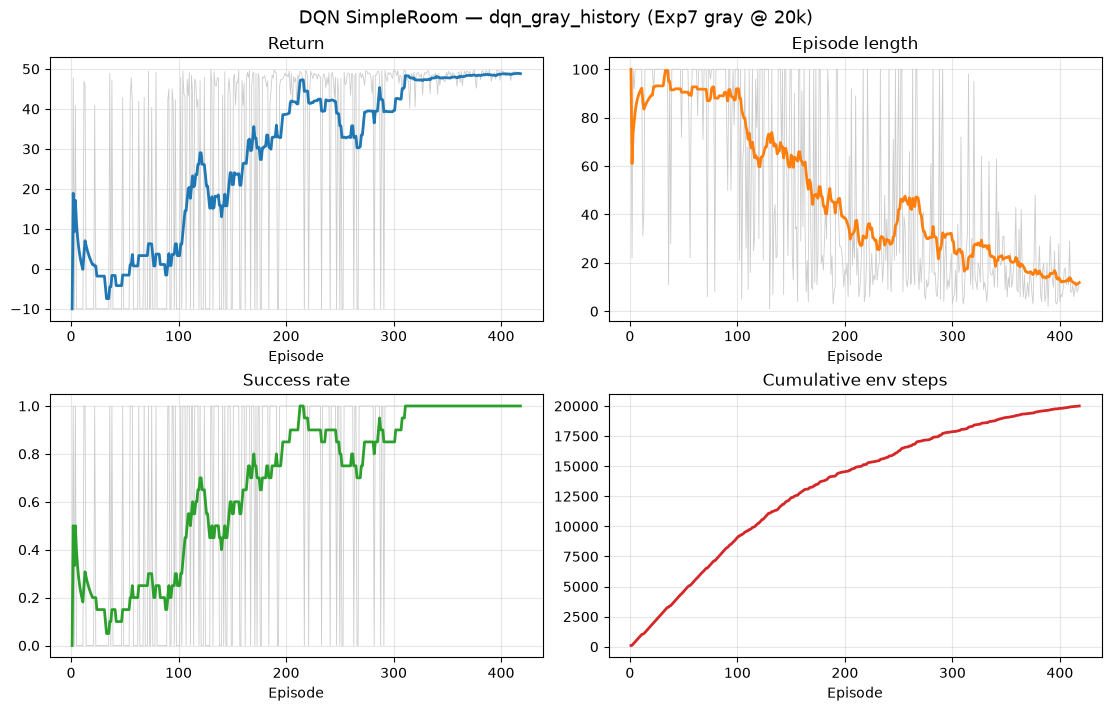

wrote:
  return     → /Users/dypaul/Personal/Masters/Reinforcmment Learning/Ex3/src/graphs/dqn_gray_history_return.png
  length     → /Users/dypaul/Personal/Masters/Reinforcmment Learning/Ex3/src/graphs/dqn_gray_history_length.png
  success    → /Users/dypaul/Personal/Masters/Reinforcmment Learning/Ex3/src/graphs/dqn_gray_history_success.png
  cum_steps  → /Users/dypaul/Personal/Masters/Reinforcmment Learning/Ex3/src/graphs/dqn_gray_history_cum_steps.png
  overview   → /Users/dypaul/Personal/Masters/Reinforcmment Learning/Ex3/src/graphs/dqn_gray_history_overview.png


In [20]:
if not RUN.get("step5_plots", False):
    print("⏭ skip: step5_plots")
else:
    import importlib
    import utils.plotting as _plot
    importlib.reload(_plot)
    from utils import (
        graphs_dir,
        load_training_history,
        pick_history,
        plot_training_history,
        save_training_history,
    )

    _hist = None
    _name = None
    try:
        _name, _hist = pick_history(
            {
                "dqn_gray_history (Exp7 gray @ 20k)": globals().get("dqn_gray_history"),
                "dqn_best_history (Exp6b RGB @ 50k)": globals().get("dqn_best_history"),
                "dqn_history (SimpleRoom train cell)": globals().get("dqn_history"),
            }
        )
    except KeyError:
        _jsons = sorted(
            list(graphs_dir().glob("dqn_*history*.json"))
            + list(graphs_dir().glob("dqn_gray_history.json"))
            + list(graphs_dir().glob("dqn_best_history.json")),
            key=lambda p: p.stat().st_mtime,
            reverse=True,
        )
        # unique preserve order
        _seen, _uniq = set(), []
        for p in _jsons:
            if p not in _seen and p.exists():
                _seen.add(p)
                _uniq.append(p)
        if not _uniq:
            raise FileNotFoundError(
                "No training history in memory or under graphs/. "
                "Re-run Exp7 (grayscale) or Exp6b train cell, then re-run this cell."
            )
        _path = _uniq[0]
        _hist = load_training_history(_path)
        _name = _path.stem
        print(f"loaded saved history: {_path}")

    _prefix = _name.split()[0]
    _json = graphs_dir() / f"{_prefix}.json"
    save_training_history(_hist, _json)
    print(f"using {_name}  |  episodes={len(_hist['episode_return'])}  |  saved {_json}")

    _saved = plot_training_history(
        _hist,
        title=f"DQN SimpleRoom — {_name}",
        save_prefix=_prefix,
        window=20,
        show=True,
    )
    print("wrote:")
    for k, p in _saved.items():
        print(f"  {k:10s} → {p}")

## Step 6a — ComplexEnv stack & event shaping

**Obs:** same spatial pipeline as SimpleRoom, **grayscale** `64×64×1` (Exp7: color was not the unlock).
**Actions:** `{left, right, forward, pickup, drop, toggle}` = ids `(0..5)` — drop MiniGrid `done`.
**Shaping:** event-only via getters (`curr and not prev`). Magnitudes **locked** for 6a (anti-farm first-time rules).

### Locked reward schedule

| Term | Draft | Notes |
|------|------:|-------|
| `goal_scale` | **50** | env `+1` → `+50` (match SimpleRoom) |
| `step_penalty` | **0.1** | match SimpleRoom |
| `key_pickup` | +5 | **first time only** (no pick/drop farm) |
| `door_open` | +10 | **first time only** |
| `enter_right_room` | +5 | **first time only**; optional flag |
| `water_pickup` | +2 | **once per original spawn tile** (drop/re-pick unpaid) |
| `lava_extinguish` | +5 | per tile this step |
| `lava_death` | −10 | terminated off-goal |

Locked: keep `enter_right_room`. Retune in 6d if needed.


In [21]:
if not RUN.get("complex_factory", False):
    print("⏭ skip: complex_factory")
else:
    import importlib
    import wrappers
    import wrappers.complex as _cx
    importlib.reload(_cx)
    importlib.reload(wrappers)
    from wrappers import (
        ComplexShapingWrapper,
        CropOuterWallsWrapper,
        DEFAULT_COMPLEX_SHAPING,
        ResizeObsWrapper,
        TileInsetWrapper,
    )

    # ComplexEnv actions: 0 left, 1 right, 2 forward, 3 pickup, 4 drop, 5 toggle, 6 done.
    _COMPLEX_ACTIONS = (0, 1, 2, 3, 4, 5)  # exclude done
    _COMPLEX_TILE = 16  # Exp13 A/B: sharper tiles before 64×64 resize
    _COMPLEX_KEEP = 0.75
    _COMPLEX_CNN = 64
    _COMPLEX_MAX_STEPS = 200  # shorter horizon: more eps/budget, less −step burn


    def make_complex_env(
        max_steps: int = _COMPLEX_MAX_STEPS,
        tile_size: int = _COMPLEX_TILE,
        keep_fraction: float = _COMPLEX_KEEP,
        cnn_size: int = _COMPLEX_CNN,
        grayscale: bool = True,  # Step 6a: gray by default (user choice)
        shaping: dict | None = None,
        use_enter_right_room: bool = True,
    ):
        """ComplexEnv + event shaping + action subset + SimpleRoom-style gray obs stack."""
        kw = dict(DEFAULT_COMPLEX_SHAPING)
        if shaping:
            kw.update(shaping)
        # strip non-wrapper keys if present
        kw.pop("use_enter_right_room", None)

        env = ComplexEnv(max_steps=max_steps, tile_size=tile_size)
        env = ComplexShapingWrapper(
            env,
            use_enter_right_room=use_enter_right_room,
            **kw,
        )
        env = ActionSubsetWrapper(env, action_ids=_COMPLEX_ACTIONS)
        env = CropOuterWallsWrapper(env)
        env = TileInsetWrapper(env, keep_fraction=keep_fraction)
        if grayscale:
            env = GrayscaleWrapper(env)
        env = ResizeObsWrapper(env, size=cnn_size)
        return env


    _probe = make_complex_env()
    print("ComplexEnv stack:")
    print(f"  obs_space   = {_probe.observation_space}")
    print(f"  action_space= {_probe.action_space}  (ids {_COMPLEX_ACTIONS}, no done)")
    _w = _probe
    while _w is not None:
        if isinstance(_w, ComplexShapingWrapper):
            print(f"  shaping_cfg = {_w.shaping_config()}")
            break
        _w = getattr(_w, "env", None)
    _probe.close()


ComplexEnv stack:
  obs_space   = Box(0, 255, (64, 64, 1), uint8)
  action_space= Discrete(6)  (ids (0, 1, 2, 3, 4, 5), no done)
  shaping_cfg = {'goal_scale': 50.0, 'step_penalty': 0.1, 'key_pickup': 5.0, 'door_open': 10.0, 'enter_right_room': 5.0, 'water_pickup': 2.0, 'lava_extinguish': 5.0, 'lava_death': 10.0, 'use_enter_right_room': True, 'anti_farm': 'first-time milestones; water once per original spawn tile', 'max_stage_shaping_est': 41.0}


In [22]:
if not RUN.get("complex_sanity", False):
    print("⏭ skip: complex_sanity")
else:
    # Sanity: random rollouts — count which shaping events fire (no DQN yet).
    from collections import Counter

    N_EPS = 30
    event_counts = Counter()
    stage_end = Counter()
    returns = []

    for ep in range(N_EPS):
        env = make_complex_env()
        obs, info = env.reset(seed=ep)
        ep_ret = 0.0
        for _ in range(_COMPLEX_MAX_STEPS):
            action = env.action_space.sample()
            obs, reward, terminated, truncated, info = env.step(action)
            ep_ret += float(reward)
            for k, v in (info.get("reward_breakdown") or {}).items():
                if k == "step_penalty":
                    continue
                if v:
                    event_counts[k] += 1
            if terminated or truncated:
                break
        for k in ("stage_key", "stage_door", "stage_right", "stage_water", "stage_lava", "stage_goal"):
            if info.get(k):
                stage_end[k] += 1
        returns.append(ep_ret)
        env.close()

    print(f"random {N_EPS} eps | mean return={sum(returns)/len(returns):.2f}")
    print("event hits (non-step):", dict(event_counts))
    print("stage reached (end of ep):", {k: f"{v}/{N_EPS}" for k, v in stage_end.items()})
    print("(Random rarely progresses — we only check the wiring does not crash and breakdown keys appear.)")


random 30 eps | mean return=-17.00
event hits (non-step): {'key_pickup': 18}
stage reached (end of ep): {'stage_key': '18/30'}
(Random rarely progresses — we only check the wiring does not crash and breakdown keys appear.)


## Step 6b — Stage metrics + ComplexEnv DQN smoke

Wire `stage_*` rates into DQN logs, then a **short** train (~10k steps) with SimpleRoom winner hypers.
Expect partial progress (key/door), not goal solves. No long train yet — that is **6c**.


In [23]:
if not RUN.get("complex_smoke", False):
    print("⏭ skip: complex_smoke")
else:
    import importlib
    import algorithms
    import algorithms.dqn as _dqn
    import algorithms.base as _base
    importlib.reload(_base)
    importlib.reload(_dqn)
    importlib.reload(algorithms)
    from algorithms import DQN
    from utils import graphs_dir, save_training_history

    # Requires make_complex_env from Step 6a cell.
    _probe = make_complex_env()
    _obs_c = _probe.observation_space.shape
    _n_act_c = _probe.action_space.n
    _probe.close()
    assert _obs_c[-1] == 1, f"expected grayscale ComplexEnv obs, got {_obs_c}"
    assert _n_act_c == 6, f"expected 6 actions (no done), got {_n_act_c}"
    print(f"ComplexEnv smoke: obs={_obs_c}  n_actions={_n_act_c}")

    # Throughput (Exp10b): ComplexEnv CPU render is fine (~0.4ms); MPS SGD is the
    # bottleneck. Prefer n_envs=1 + higher train_freq on Mac. On Colab CUDA you can
    # try n_envs=4..8. Hard target (tau=1) avoids per-update soft-sync cost.
    _SMOKE_STEPS = 10_000
    _N_ENVS = 1
    _COMPLEX_HPARAMS = {
        "lr": 2.81e-4,
        "gamma": 0.95,
        "batch_size": 64,
        "train_freq": 8,
        "gradient_steps": 1,
        "tau": 1.0,
        "target_update_freq": 500,
        "eps_start": 1.0,
        "eps_end": 0.15,
        "eps_decay_steps": 20_000,
        "learning_starts": 1_000,
        "double_dqn": True,
        "buffer_size": 50_000,
        "log_loss_every": 50,
    }

    dqn_complex_smoke = DQN(_obs_c, _n_act_c, device=device, seed=0, **_COMPLEX_HPARAMS)
    print(dqn_complex_smoke)
    print(
        f"smoke: {_SMOKE_STEPS} steps, n_envs={_N_ENVS}, "
        f"train_freq={_COMPLEX_HPARAMS['train_freq']}, batch={_COMPLEX_HPARAMS['batch_size']}"
    )
    dqn_complex_smoke_history = dqn_complex_smoke.train(
        make_complex_env,
        total_timesteps=_SMOKE_STEPS,
        log_every=1_000,
        n_envs=_N_ENVS,
    )

    _hist_path = graphs_dir() / "dqn_complex_smoke_history.json"
    save_training_history(dqn_complex_smoke_history, _hist_path)
    print(f"history saved: {_hist_path}")

    # Episode-level stage rates over the whole smoke run
    for sk in ("stage_key", "stage_door", "stage_right", "stage_water", "stage_lava", "stage_goal"):
        vals = dqn_complex_smoke_history.get(sk) or []
        if vals:
            print(f"  {sk:12s}  mean={sum(vals)/len(vals):5.1%}  over {len(vals)} eps")

    eval_env = make_complex_env()
    print("greedy eval:", dqn_complex_smoke.evaluate(eval_env, n_episodes=10, seed=200))
    eval_env.close()

ComplexEnv smoke: obs=(64, 64, 1)  n_actions=6
DQN(obs_shape=(64, 64, 1), n_actions=6, device=mps, steps=0)
smoke: 10000 steps, n_envs=1, train_freq=8, batch=64
steps=   4000  episodes=   20  return= -15.00  mean20= -16.00  succ20= 0.0%  eps=0.830  key= 80% door=  0% right=  0% water=  0% lava=  0% goal=  0%
steps=   8000  episodes=   40  return= -20.00  mean20= -18.25  succ20= 0.0%  eps=0.660  key= 35% door=  0% right=  0% water=  0% lava=  0% goal=  0%
history saved: /Users/dypaul/Personal/Masters/Reinforcmment Learning/Ex3/src/graphs/dqn_complex_smoke_history.json
  stage_key     mean=60.0%  over 50 eps
  stage_door    mean= 2.0%  over 50 eps
  stage_right   mean= 2.0%  over 50 eps
  stage_water   mean= 2.0%  over 50 eps
  stage_lava    mean= 0.0%  over 50 eps
  stage_goal    mean= 0.0%  over 50 eps
greedy eval: {'mean_return': -20.00000000000001, 'std_return': 3.552713678800501e-15, 'mean_length': 200.0, 'success_rate': 0.0, 'n_episodes': 10.0, 'stage_key': 0.0, 'stage_door': 0.0, 

## Step 6c — Overnight ComplexEnv DQN sweep (door-focused)

Exp11 (Colab ~132k) showed **key sometimes, door almost never**. So 6c is not “one longer train” — it is a **grid** of DQN + shaping variants, ranked by `stage_door` / later stages.

**Runner (outside the notebook loop):** `scripts/overnight_complex.py`  
**Outputs:** `graphs/overnight_complex/` (per-trial history, plots, checkpoints) + `LEADERBOARD.md`

| Phase | What | Budget |
|-------|------|--------|
| A | 10 shaping presets | 80k |
| B | 14 DQN presets (+ door_heavy) | 80k |
| C | gray vs RGB | 80k |
| D | horizon 150/200/300 | 80k |
| E/F | deep best-bets | 250k |

Re-run the next cell anytime to **status / leaderboard**. Set `RUN["complex_overnight"]=True` only if you want this notebook to **start** a new sweep (skips trials that already finished).

**Exp13 (running):** 2×2 `tile∈{12,16}` × `width_mult∈{1,2}` on winner recipe → `graphs/ab_tile_arch/`.


In [24]:
# Step 6c — overnight sweep status / optional launch
from pathlib import Path
import json
import os
import subprocess
import time

_ROOT = Path.cwd()
_OUT = _ROOT / "graphs" / "overnight_complex"
_SCRIPT = _ROOT / "scripts" / "overnight_complex.py"
_LOG = _OUT / "run.log"
_LB = _OUT / "LEADERBOARD.md"
_PID_FILE = _OUT / "overnight.pid"

def _overnight_pids():
    try:
        out = subprocess.check_output(["pgrep", "-fl", "overnight_complex"], text=True)
    except subprocess.CalledProcessError:
        return []
    rows = []
    for line in out.strip().splitlines():
        if "python" in line and "overnight_complex.py" in line:
            rows.append(line)
    return rows

pids = _overnight_pids()
print(f"output dir: {_OUT}")
print(f"running: {len(pids)} process(es)")
for p in pids:
    print(f"  {p}")

finished = sorted(_OUT.glob("*/result.json"))
print(f"finished trials: {len(finished)}")
if finished:
    latest = max(finished, key=lambda p: p.stat().st_mtime)
    r = json.loads(latest.read_text())
    late = r.get("late_stages", {})
    print(
        f"latest: {r.get('name')}  door_late={late.get('stage_door', 0):.0%}  "
        f"key_late={late.get('stage_key', 0):.0%}  score={r.get('score', 0):.1f}"
    )

if _LB.exists():
    print("\n----- LEADERBOARD (top) -----")
    print("\n".join(_LB.read_text().splitlines()[:18]))
elif _LOG.exists():
    print("\n----- run.log (tail) -----")
    print("\n".join(_LOG.read_text().splitlines()[-25:]))
else:
    print("No leaderboard/log yet.")

# Launch only if explicitly enabled (multi-hour job).
if not RUN.get("complex_overnight", True):
    print("\n⏭ skip launch: set RUN['complex_overnight']=True to start/resume from this cell")
    print("   (a background sweep may already be running from the terminal)")
else:
    if pids:
        print("\nAlready running — not starting a second sweep.")
    else:
        _OUT.mkdir(parents=True, exist_ok=True)
        env = os.environ.copy()
        env["MPLCONFIGDIR"] = str(_OUT / ".mpl")
        (_OUT / ".mpl").mkdir(exist_ok=True)
        log_f = open(_LOG, "a", buffering=1)
        proc = subprocess.Popen(
            [
                str(_ROOT / ".venv" / "bin" / "python"),
                "-u",
                str(_SCRIPT),
                "--short-steps", "80000",
                "--long-steps", "250000",
            ],
            cwd=str(_ROOT),
            env=env,
            stdout=log_f,
            stderr=subprocess.STDOUT,
            start_new_session=True,
        )
        _PID_FILE.write_text(str(proc.pid))
        print(f"\n▶ launched overnight PID={proc.pid}")
        print(f"   log: {_LOG}")
        time.sleep(2)
        print("\n".join(_LOG.read_text().splitlines()[-15:]))


output dir: /Users/dypaul/Personal/Masters/Reinforcmment Learning/Ex3/src/graphs/overnight_complex
running: 0 process(es)
finished trials: 42
latest: F_sparse_mid_slow  door_late=0%  key_late=78%  score=0.4

----- LEADERBOARD (top) -----
# Overnight ComplexEnv leaderboard

Generated: 2026-07-18T03:20:48.221674+00:00
Trials finished: 42

| rank | name | score | eval_succ | eval_door | late_door | late_key | steps | min |
|-----:|------|------:|----------:|----------:|----------:|---------:|------:|----:|
| 1 | `E_deep_frequent` | 9.7 | 0% | 47% | 46% | 66% | 250000 | 52.0 |
| 2 | `E_deep_rgb_extreme` | 8.7 | 0% | 27% | 32% | 44% | 250000 | 16.7 |
| 3 | `B_dqn_big_batch` | 2.2 | 0% | 7% | 12% | 76% | 80000 | 15.6 |
| 4 | `E_deep_door_sloweps` | 1.2 | 0% | 0% | 0% | 68% | 250000 | 16.2 |
| 5 | `E_deep_soft_door` | 1.0 | 0% | 0% | 0% | 68% | 250000 | 16.5 |
| 6 | `E_deep_lowstep_slow` | 0.9 | 0% | 0% | 2% | 64% | 250000 | 16.1 |
| 7 | `E_deep_rgb_door` | 0.9 | 0% | 0% | 6% | 84% | 250000 |